<a href="https://colab.research.google.com/github/WajdAlsuhaymi/IT326-DataMining-Group2/blob/main/Reports/Report_phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem

Many individuals use social media daily without realizing its emotional impact. Excessive or unbalanced usage can lead to anxiety, sadness, boredom, and other negative states. The lack of awareness and early detection makes it harder to intervene before emotional distress escalates. This project tackles the problem by using data mining to identify risky usage patterns and predict emotional outcomes.



# Data Mining Task

This project applies two main data mining tasks:

Classification Task:
The goal is to predict the user's dominant emotional state (Dominant_Emotion), which includes categories like Happiness, Sadness, Anger, Anxiety, Boredom, and Neutral. This is a multi-class classification problem where we aim to classify individuals based on their social media usage patterns—such as time spent, posts per day, likes, comments, and platform used. By doing so, we can identify users at risk of negative emotional states and support early awareness and intervention.                                                                                                                                                            
Clustering Task:
This task aims to group users into clusters based on similarities in their social media behavior and engagement metrics. By analyzing features like usage time, interaction levels, and platform preferences, clustering helps uncover hidden subgroups—such as highly active users, passive users, or emotionally vulnerable groups. These insights can guide personalized recommendations and mental health strategies.


# Data

Dataset Source
Kaggle: https://www.kaggle.com/datasets/emirhanai/social-media-usage-and-emotional-well-being

Step A: Importing the dataset - Reading from local file...
Path to dataset file: https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv
Dataset loaded successfully.

Step B: Understanding the Dataset
The dataset consists of rows and columns containing various features related to social media usage and emotional well-being.
Rows: 924, Columns: 10
Column names: ['User_ID', 'Age', 'Gender', 'Platform', 'Daily_Usage_Time (minutes)', 'Posts_Per_Day', 'Likes_Received_Per_Day', 'Comments_Received_Per_Day', 'Messages_Sent_Per_Day', 'Dominant_Emotion']

Data Types of Columns:
User_ID                       float64
Age                           float64
Gender                         object
Platform                       object
Daily_Usage_Time (minutes)    float64
Posts_Per_Day                 float64
Likes_Received_Per_Day        float64
Comments_Received_Per_Day     float64
Messages_Sent_Per_Day         float64
Dominant_Emotion               object


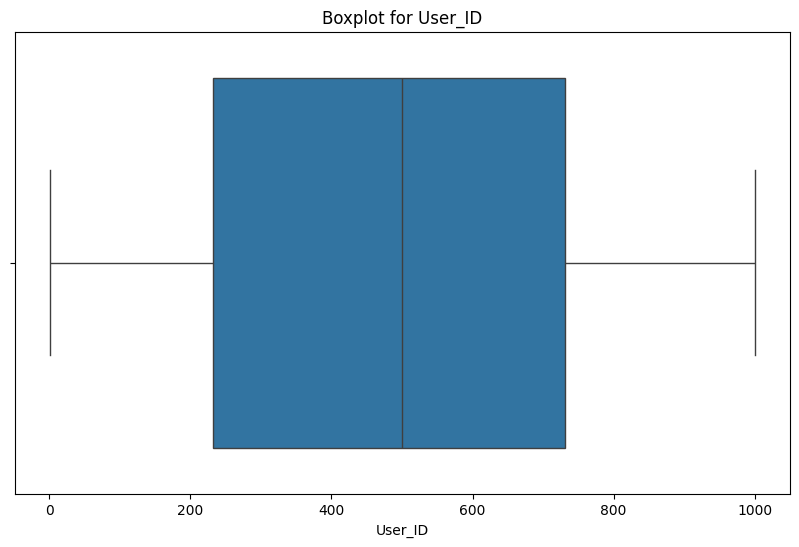

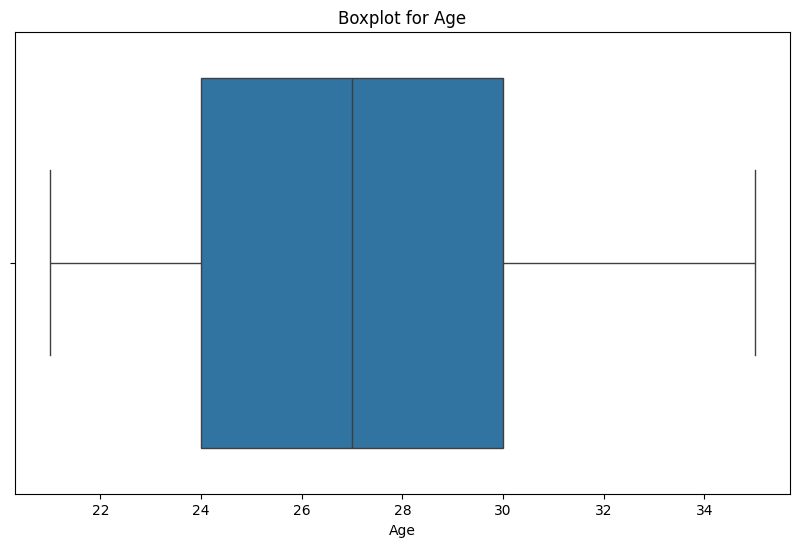

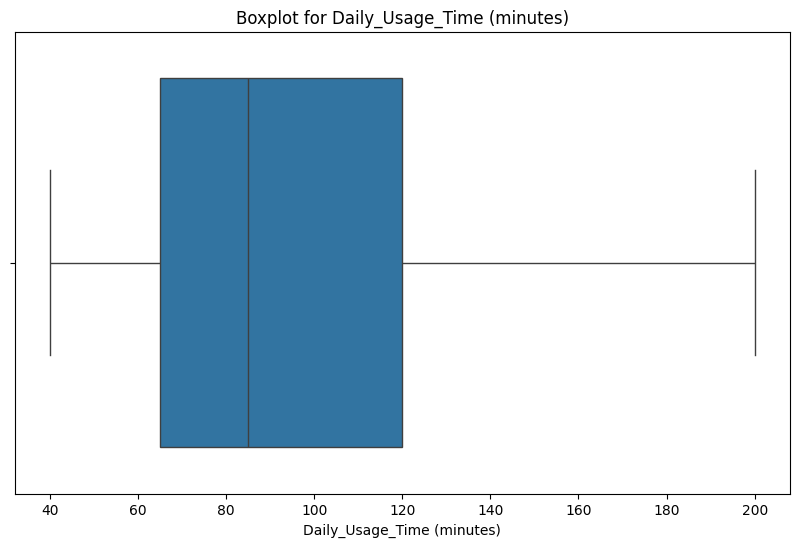

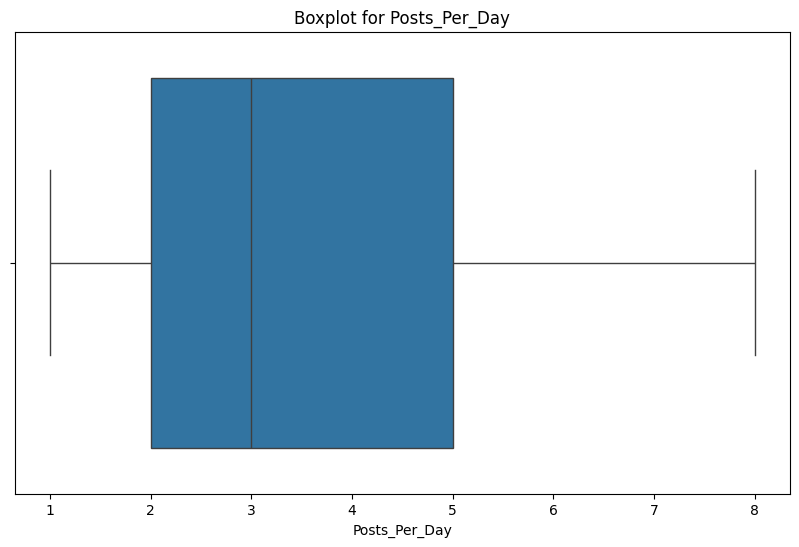

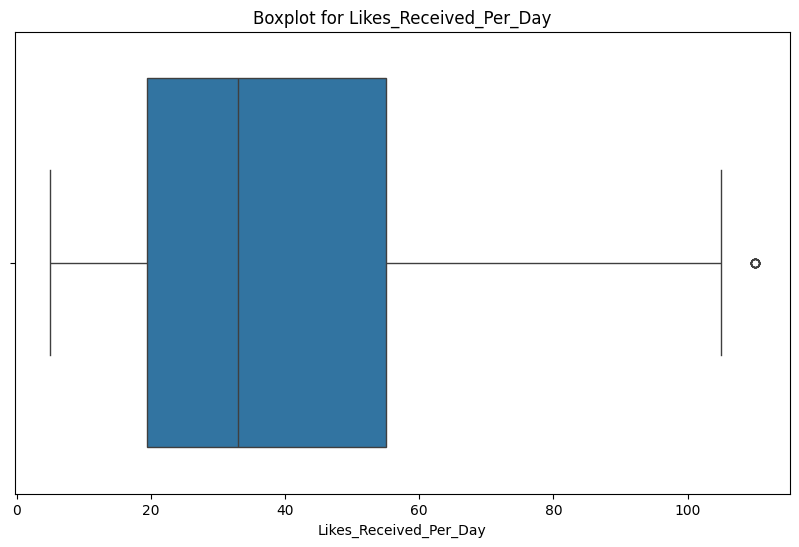

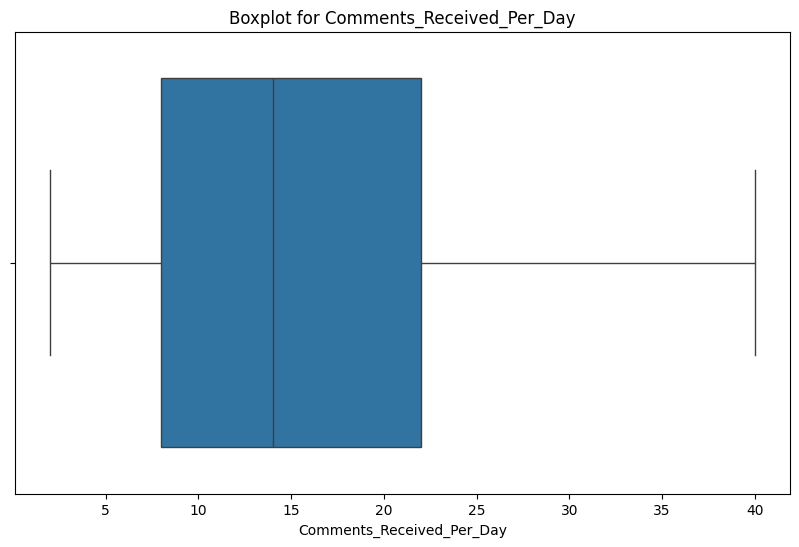

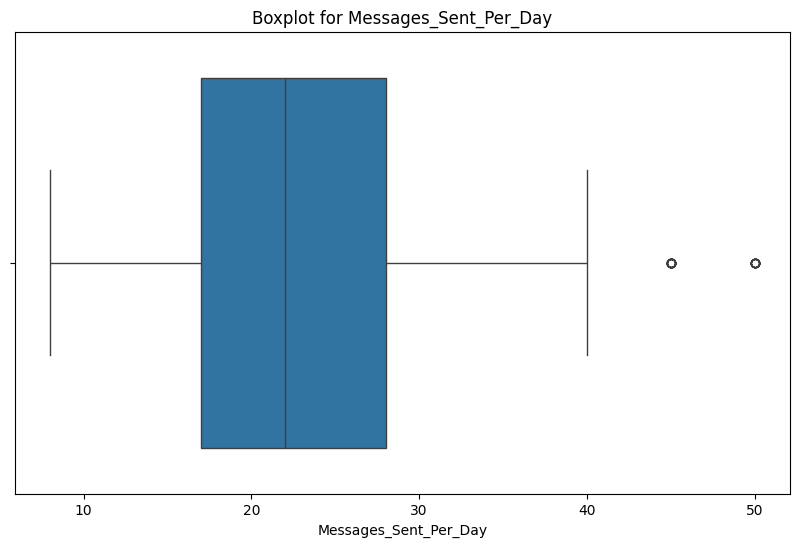


Step E: Data Visualization
Generating plots to understand feature distributions and relationships.

1. Histogram for Daily Usage Time:


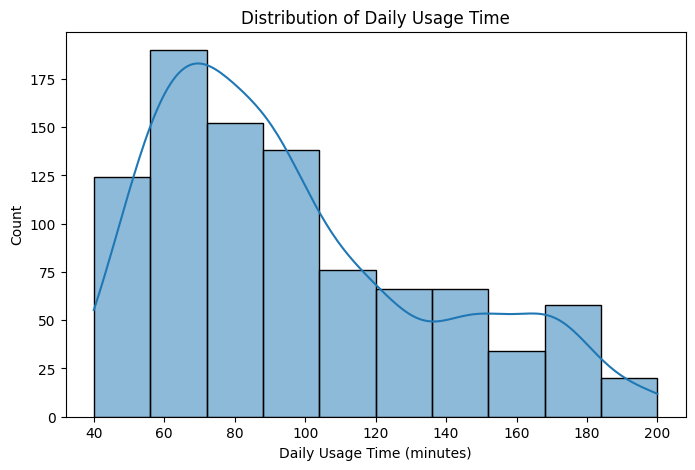

This histogram shows the distribution of daily social media usage time across the dataset. It helps understand user engagement patterns and identify common usage durations.

2. Bar Plot for Dominant Emotion Distribution:


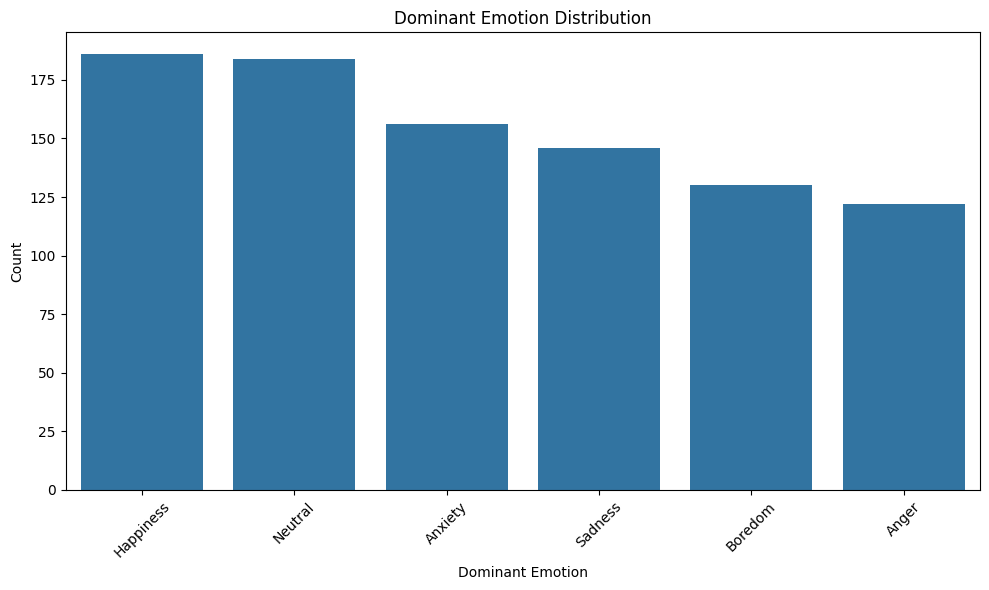

This bar plot shows the distribution of dominant emotions in the dataset. It's a nominal variable, and the count plot allows us to see the frequency of each emotional state among users.

3. Scatter Plot for Daily Usage Time vs Likes Received:


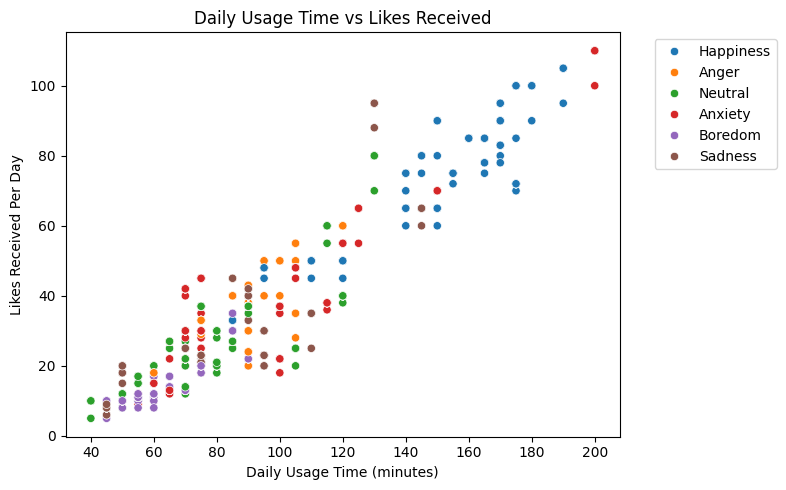

This scatter plot helps visualize the relationship between daily usage time and likes received.It can help identify any trends or patterns that might suggest a correlation between social media engagement and emotional states.

4. Correlation Heatmap of Numeric Features:


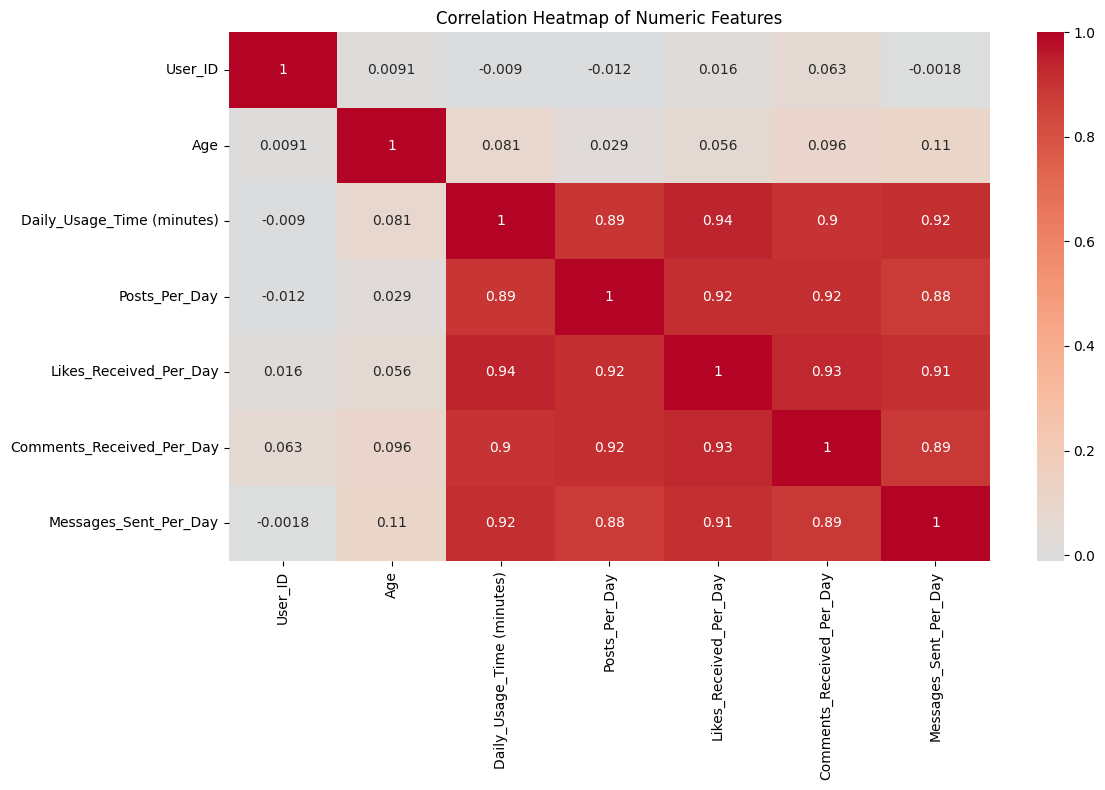

This heatmap shows the correlation between all numeric features. Strong correlations (close to 1 or -1) indicate relationships that might be important for our data mining tasks.

Concluding Observations from the Plots and Data Exploration:
From the above visualizations and statistical summaries, we can observe the following:
- The Dominant_Emotion distribution shows a relatively balanced dataset with Happiness and Neutral being the most common emotions.
- The Daily_Usage_Time distribution appears to have a normal distribution with some users showing extremely high usage patterns.
- The scatter plot between Daily_Usage_Time and Likes_Received_Per_Day suggests a positive correlation, indicating that active users tend to receive more engagement.
- The correlation heatmap reveals strong relationships between engagement metrics (Likes, Comments, Messages) and usage time.
- There are several potential outliers detected in engagement metrics that need to be addressed for better model performa

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step A: Import the dataset
print("Step A: Importing the dataset - Reading from local file...")
dataset_path = 'https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv'
print("Path to dataset file:", dataset_path)

def load_dataset():
    try:
        data = pd.read_csv(dataset_path)
        print("Dataset loaded successfully.")
        return data
    except FileNotFoundError:
        print(f"Could not find the dataset at: {dataset_path}. Please check the file name and path.")
        return None

data = load_dataset()

if data is not None:
    # Step B: Dataset Overview
    print("\nStep B: Understanding the Dataset")
    print("The dataset consists of rows and columns containing various features related to social media usage and emotional well-being.")
    print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")
    print("Column names:", data.columns.tolist())

    # Data types of the columns
    print("\nData Types of Columns:")
    print(data.dtypes)

    # Missing values
    print("\nMissing Values in Each Column:")
    print(data.isnull().sum())

    # Step C: Statistical Summary (Five-number summary, including outliers)
    print("\nStep C: Statistical Summary")
    print("We calculate statistical measures such as mean, variance, and percentiles to understand data distribution.")
    print(data.describe())

    # Step D: Class Label Distribution (Detect Class Imbalance)
    print("\nStep D: Analyzing Class Distribution")
    print("Checking the distribution of the class label to detect any imbalances in the dataset.")
    print(data['Dominant_Emotion'].value_counts())

    # Boxplot for numeric features to visualize potential outliers
    print("\nVisualizing Numeric Features with Boxplots:")
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=data[col])
        plt.title(f'Boxplot for {col}')
        plt.xlabel(col)
        plt.show()

    # Step E: Data Visualization - Variable Distributions
    print("\nStep E: Data Visualization")
    print("Generating plots to understand feature distributions and relationships.")

    # 1. Histogram for Daily Usage Time (numeric attribute)
    print("\n1. Histogram for Daily Usage Time:")
    plt.figure(figsize=(8, 5))
    sns.histplot(data['Daily_Usage_Time (minutes)'], bins=10, kde=True)
    plt.title('Distribution of Daily Usage Time')
    plt.xlabel('Daily Usage Time (minutes)')
    plt.ylabel('Count')
    plt.show()
    print("This histogram shows the distribution of daily social media usage time across the dataset. It helps understand user engagement patterns and identify common usage durations.")

    # 2. Bar plot for Dominant Emotion (nominal attribute)
    print("\n2. Bar Plot for Dominant Emotion Distribution:")
    plt.figure(figsize=(10, 6))
    sns.countplot(x='Dominant_Emotion', data=data, order=data['Dominant_Emotion'].value_counts().index)
    plt.title('Dominant Emotion Distribution')
    plt.xlabel('Dominant Emotion')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print("This bar plot shows the distribution of dominant emotions in the dataset. It's a nominal variable, and the count plot allows us to see the frequency of each emotional state among users.")

    # 3. Scatter plot for Daily Usage Time vs Likes Received (numeric attributes)
    print("\n3. Scatter Plot for Daily Usage Time vs Likes Received:")
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=data['Daily_Usage_Time (minutes)'], y=data['Likes_Received_Per_Day'], hue=data['Dominant_Emotion'])
    plt.title('Daily Usage Time vs Likes Received')
    plt.xlabel('Daily Usage Time (minutes)')
    plt.ylabel('Likes Received Per Day')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    print("This scatter plot helps visualize the relationship between daily usage time and likes received.It can help identify any trends or patterns that might suggest a correlation between social media engagement and emotional states.")

    # 4. Correlation Heatmap
    print("\n4. Correlation Heatmap of Numeric Features:")
    plt.figure(figsize=(12, 8))
    numeric_data = data.select_dtypes(include=[np.number])
    correlation_matrix = numeric_data.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()
    print("This heatmap shows the correlation between all numeric features. Strong correlations (close to 1 or -1) indicate relationships that might be important for our data mining tasks.")

    print("\nConcluding Observations from the Plots and Data Exploration:")
    print("From the above visualizations and statistical summaries, we can observe the following:")
    print("- The Dominant_Emotion distribution shows a relatively balanced dataset with Happiness and Neutral being the most common emotions.")
    print("- The Daily_Usage_Time distribution appears to have a normal distribution with some users showing extremely high usage patterns.")
    print("- The scatter plot between Daily_Usage_Time and Likes_Received_Per_Day suggests a positive correlation, indicating that active users tend to receive more engagement.")
    print("- The correlation heatmap reveals strong relationships between engagement metrics (Likes, Comments, Messages) and usage time.")
    print("- There are several potential outliers detected in engagement metrics that need to be addressed for better model performance.")
    print("Based on these insights, it is clear that the dataset is well-suited for both classification (predicting emotions) and clustering (grouping similar users) tasks.")


# Data Preprocessing
Preprocessing Steps:

Removed irrelevant columns

Encoded Dominant_Emotion into numeric Emotion_Score

Normalized numerical features

Removed missing values

Prepared df_cluster for unsupervised learning